<a href="https://colab.research.google.com/github/santiagoramosg/intro-a-la-ia-aprendizaje-no-supervisado/blob/main/metricas_kmeans_dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

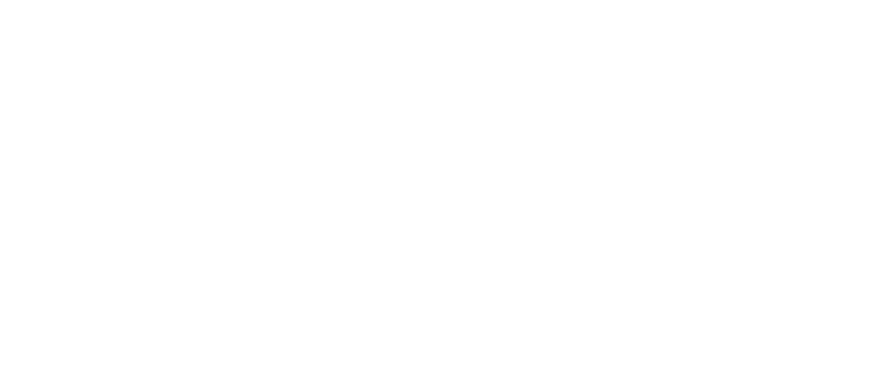

# Taller Introducción a la IA: Métricas Aprendizaje Supervisado


## No olvide escribir su correo y nombre, para la entrega del taller y posterior calificación

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Creamos el dataset

In [ ]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creamos el modelo

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

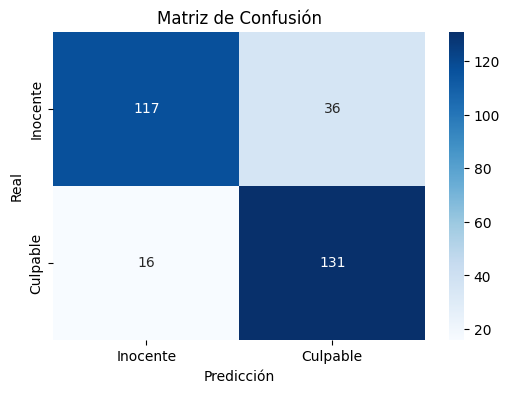

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Inocente", "Culpable"], yticklabels=["Inocente", "Culpable"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
VP = cm[0,0]  # Verdaderos Positivos
FN = cm[0,1]  # Falsos Negativos
FP = cm[1,0]  # Falsos Positivos
VN = cm[1,1]  # Verdaderos Negativos

print(f"VP: {VP}")
print(f"FN: {FN}")
print(f"FP: {FP}")
print(f"VN: {VN}")

VP: 117
FN: 36
FP: 16
VN: 131


In [ ]:
# Utilizando las variables anteriores:

accuracy = (VP+VN)/(VP+VN+FP+FN)  # Completa la fórmula para la exactitud (accuracy)
precision = VP/(VP+FP)  # Completa la fórmula para la precisión (precision)
recall = VP/(VP+FN) # Completa la fórmula para el recall
f1_score = 2*((precision*recall)/(precision+recall)) # Completa la fórmula para el F1-score
fpr=FP/(FP+VN)

In [ ]:
print(f"Exactitud (Accuracy): {accuracy:.2f}")
print(f"Precisión (Precision): {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Exactitud (Accuracy): 0.83
Precisión (Precision): 0.88
Recall: 0.76
F1-Score: 0.82


In [ ]:
"""
Importante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

"""

'\nImportante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report\n\n\nfrom sklearn.metrics import classification_report\n\nprint(classification_report(y_test, y_pred))\n\n'

In [ ]:
# Obtener puntajes de decisión o probabilidades para la clase positiva
# (completa con decision_function o predict_proba)
y_scores = svm_model.decision_function(X_test)

In [ ]:
df_scores = pd.DataFrame(y_scores, columns=["Score"])
print(df_scores.head())

      Score
0  2.062054
1 -4.081137
2 -3.131730
3  0.533541
4 -3.288151


In [ ]:
# Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test,y_pred)

In [ ]:
# Calcular el AUC (Área bajo la curva)
auc_score = roc_auc_score(y_test, y_pred)

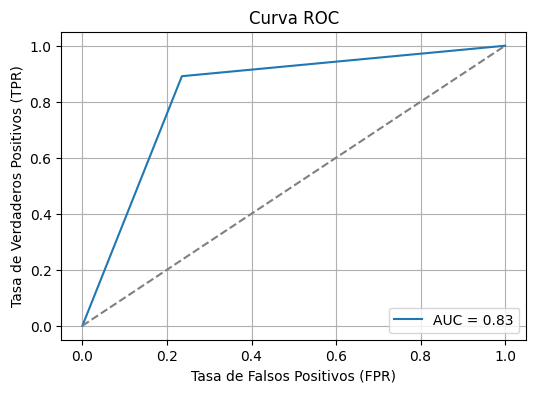

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

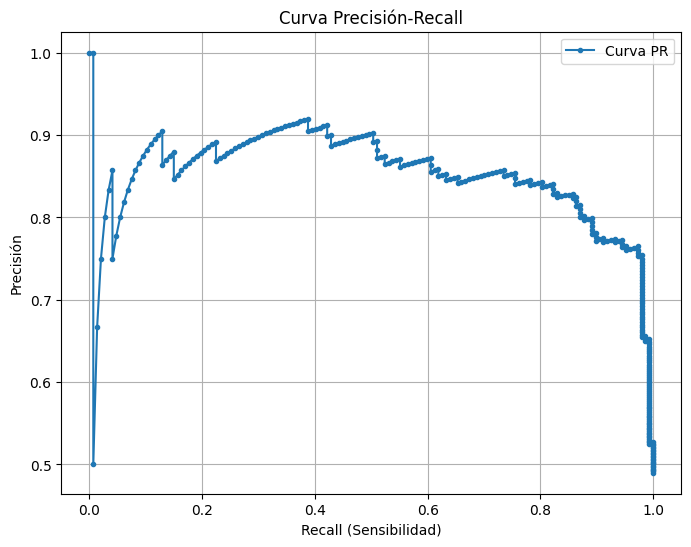

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Curva PR')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
auc_pr = auc(recall, precision)
print(f"Área Bajo la Curva PR (AUC-PR): {auc_pr:.4f}")

Área Bajo la Curva PR (AUC-PR): 0.8504


# **PREGUNTAS**




1. **¿Cuál fue el valor del recall?**  
el recall tuvo un valor de 0.76 significando un 76.47% de precision al detectar inocentes



2. **¿En qué situación podría ser preferible
tener un modelo con alto recall pero baja precisión en este concurso de detectives? ¿Deberías desconfiar en el modelo a pesar del buen recall? Justifica tu respuesta en el contexto del problema.**  

un alto recall puede ser preferible si se considera que es preferible un falso negativo a un falso positivo en este caso  
sin embargo estos modelos al tener un recall alto posee una precision deficiente

3. **Si el organizador del concurso cambia las reglas para penalizar más los falsos positivos que los falsos negativos, ¿qué métrica deberías optimizar y por qué?**

se deberia optimizar es la precision dado que es la que mide la precision al acusar inocentes

4. **Si decides comparar varios modelos utilizando la curva ROC y el AUC y la curva PR y , ¿qué representa esta métrica en el contexto del concurso? ¿Por qué podría ser más útil que el accuracy cuando las clases están desbalanceadas (pocos culpables y muchos inocentes en el conjunto de datos)?**  

el ROC representa la relación entre culpables bien identificados e inocentes acusados indebidamente, el UAC representa el area bajo esa curva, significando la precision de correcta discriminacion, y la curva PR es la relacion entre el precision y el recall  

es mejor el ROC y el PR dado que si las clases son muy desbalanceadas, el modelo probablemente prediga incorrectamente la clase con menos datos

5. **¿Por qué el F1-Score se considera una de las métricas más importantes para evaluar modelos de clasificación?**  

es importante dado que es la medida que involucra el precision y el recall, siendo robusto al desbalance de datos y dando un equilibrio en las metricas

6. Supón que tu modelo tiene una precisión de 0.95 pero un recall de 0.40. ¿Cómo interpretas esto en términos de desempeño del detective? ¿Qué dice esto sobre los sospechosos culpables?  

significa que cuando el detective acusa a alguien acierta un 95% de las veces, pero de todos los culpables, el detective solo identifica al 40% de ellos correctamente

7. Realice el siguiente cálculo a mano de las cuatro métricas vistas en clase, determine la cantidad de Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos, Falsos Negativos para cada clase y calcula el Accuracy global.

Clase A:
VP = 30
FN = 5 + 10 = 15
FP = 3 + 2 = 5
VN = 25 + 12 + 6 + 27 = 70

Clase B:
VP = 25
FN = 3 + 12 = 15
FP = 5 + 6 = 11
VN = 30 + 10 + 2 + 27 = 69

Clase C:
VP = 27
FN = 2 + 6 = 8
FP = 10 + 12 = 22
VN = 30 + 5 + 3 + 25 = 63

Accuracy = (30 + 25 + 27) / 120 = 0.683 = 68.3%

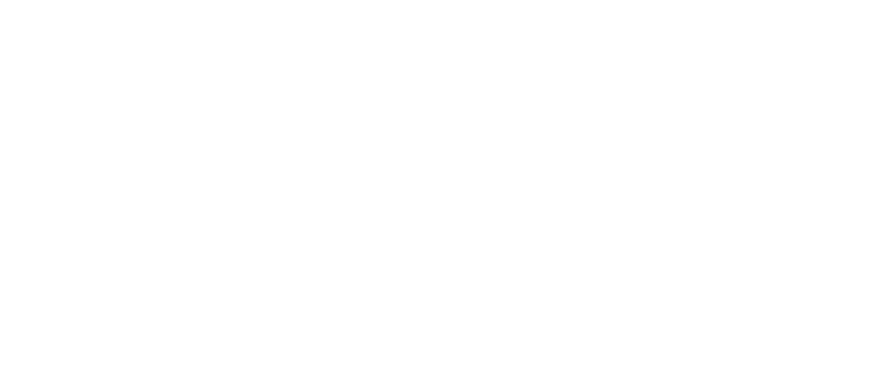

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
X, y = make_blobs(n_samples=400,
                  centers=4,
                  cluster_std=1.5,
                  random_state=42)

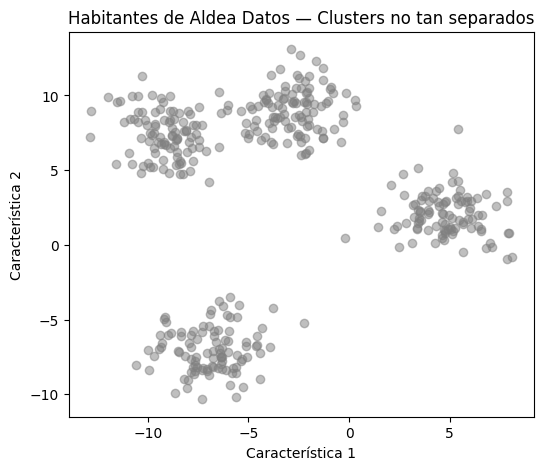

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
plt.title("Habitantes de Aldea Datos — Clusters no tan separados")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [ ]:
silhouette_scores = []
inertias = [] # SSE
k_values = range(2, 8)

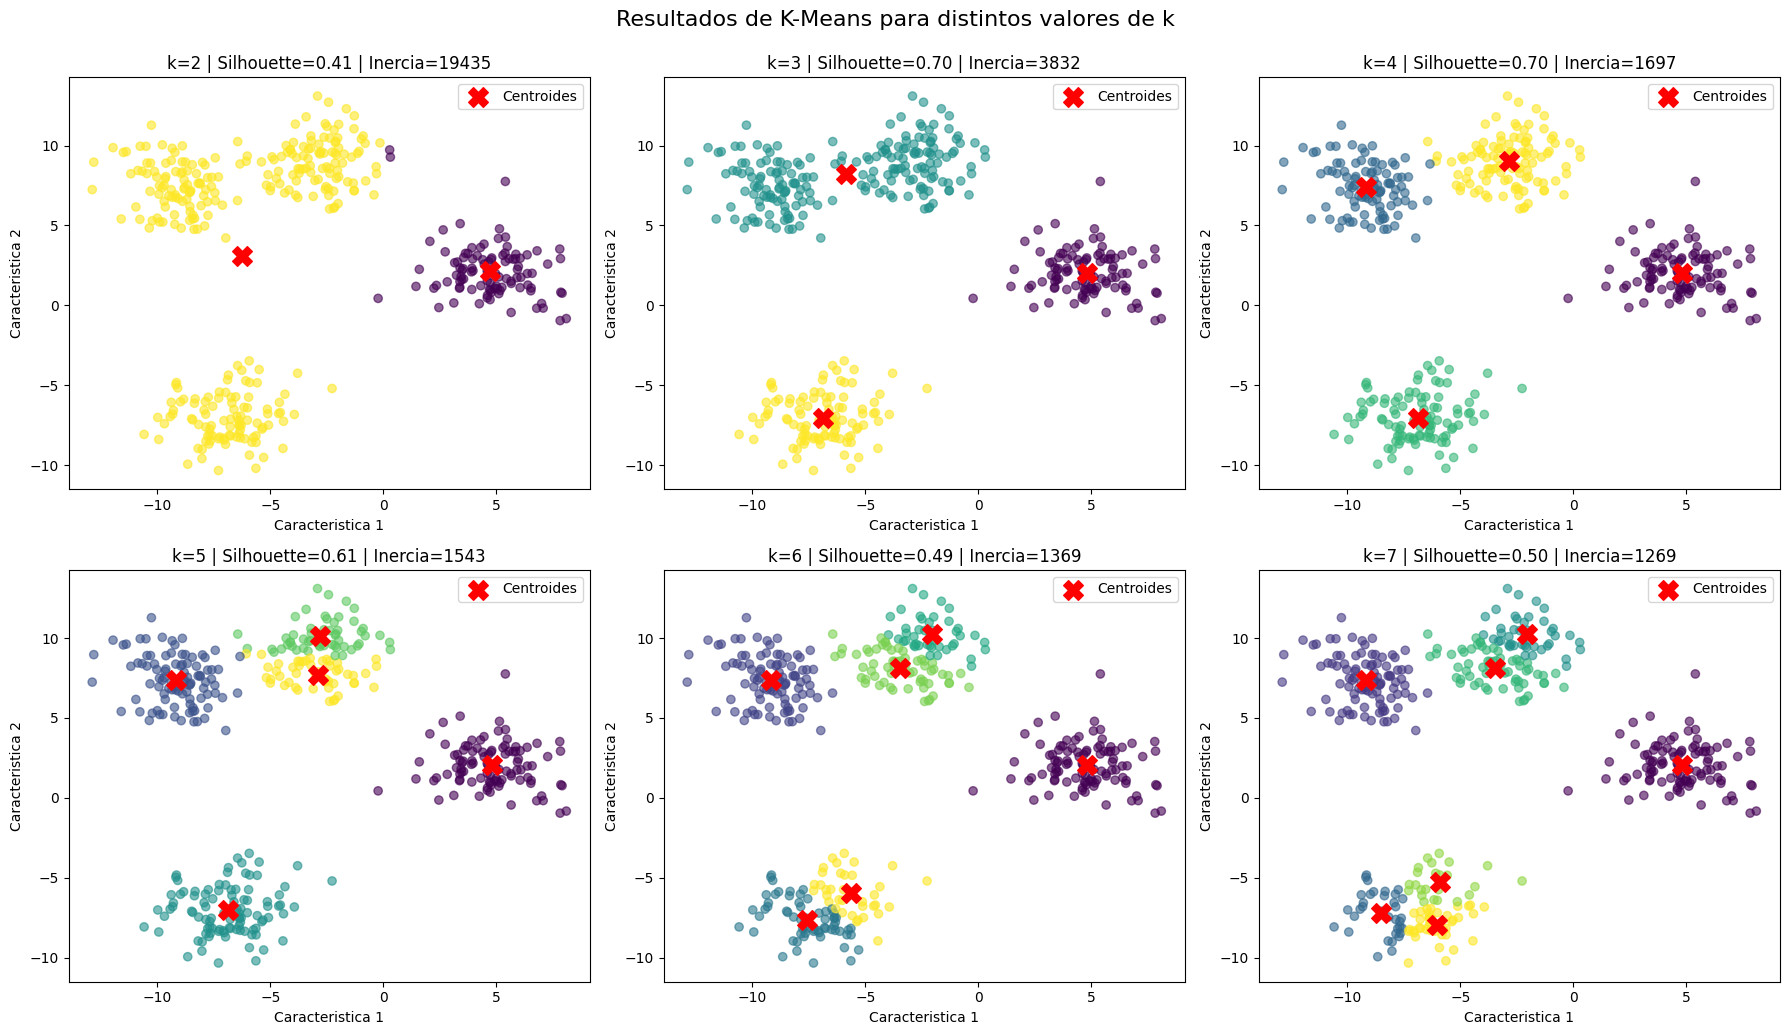

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)  # Define el numero de clusters
    labels = kmeans.fit_predict(X)                   # Aplica el modelo y obtiene las etiquetas
    centers = kmeans.cluster_centers_                # Obtiene las coordenadas de los centroides
    inertia = kmeans.inertia_                        # Inercia: suma de distancias intra-cluster
    score = silhouette_score(X, labels)              # Calcula el Silhouette Score

    silhouette_scores.append(score)
    inertias.append(inertia)


    axs[idx].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axs[idx].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroides')
    axs[idx].set_title(f"k={k} | Silhouette={score:.2f} | Inercia={inertia:.0f}")
    axs[idx].set_xlabel("Caracteristica 1")
    axs[idx].set_ylabel("Caracteristica 2")
    axs[idx].legend()

plt.tight_layout()
plt.suptitle("Resultados de K-Means para distintos valores de k", fontsize=16, y=1.03)
plt.show()

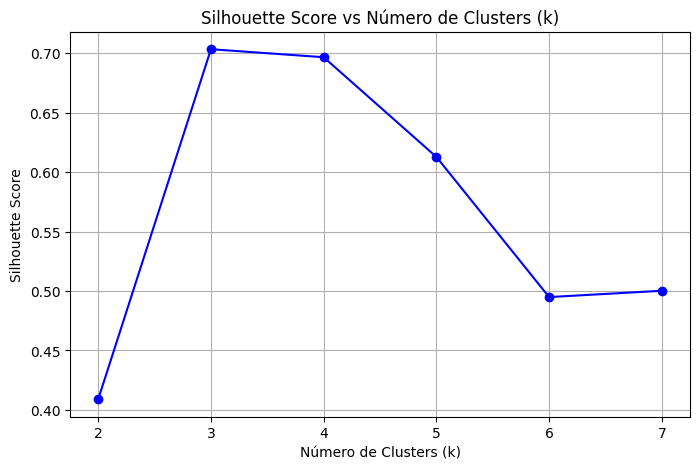

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title("Silhouette Score vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

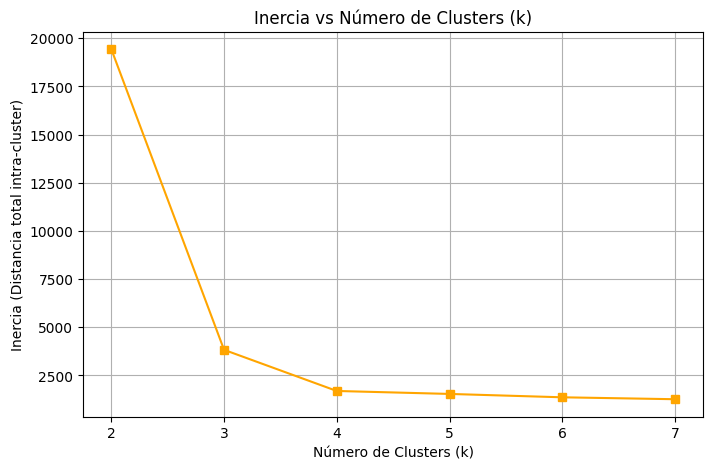

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='s', color='orange')
plt.title("Inercia vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Distancia total intra-cluster)")
plt.grid(True)
plt.show()

# **Preguntas**

1. **Si en la aldea hay una gran mayoría de personas en un grupo y muy pocos en otros, ¿cómo podría afectar esto la formación de los clústers? ¿Qué tipo de sesgo se podría generar en la agrupación?**


si unos miembros estan muy alejados de su grupo respectivo, puede afectar el centroide, dado que kmeans calcula el promedio de posicion de todos sus miembros y no puede identificar ruido.

2. **Supón que el nuevo habitante está muy lejos del resto de la aldea. ¿Qué implicaciones tiene esto para el modelo K-Means? ¿Cómo lo clasificaría el algoritmo y qué tan confiable sería esa asignación?**

esa asignacion seria de confiabilidad baja dado que como kmeans no puede identificar ruido, forzaria una asignacion, aunque este dato no pertenezca a ningun grupo

3. **Si un grupo de habitantes está ubicado entre dos clústers claramente formados, ¿cómo afecta esto al resultado del algoritmo? ¿Qué papel juega el valor de K en este tipo de situaciones?**  

dependiento la distancia a la que este este grupo de cada cluster puede suceder una de dos cosas,  
1 el grupo completo va a ser asignado a un cluster independientemente de su pertenencia o distancia  
2 el grupo puede ser dividido hasta k sub grupos para ser asignados a sus respectivos clusters si el sistema lo determina pertinente

4. **¿Cuál fue la cantidad óptima de clústers según los criterios mencionados en clase?**

3 dado que es donde se aprecia el codo de la grafica

5. Utilice la siguiente hoja de excel para realizar una actualización de los centroides en el contexto del algoritmo de KNN.

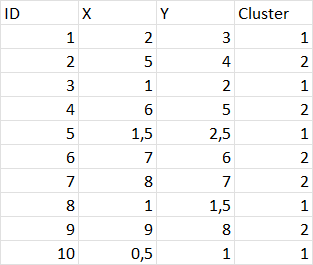
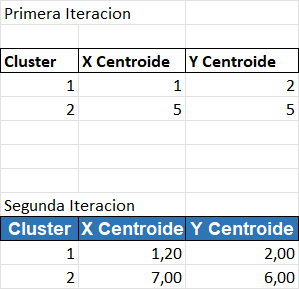
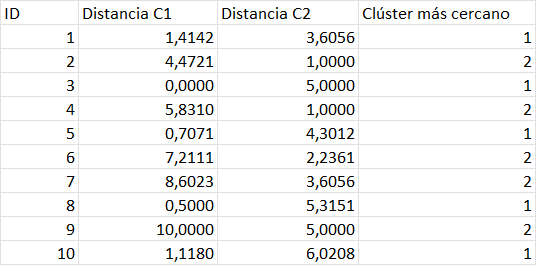


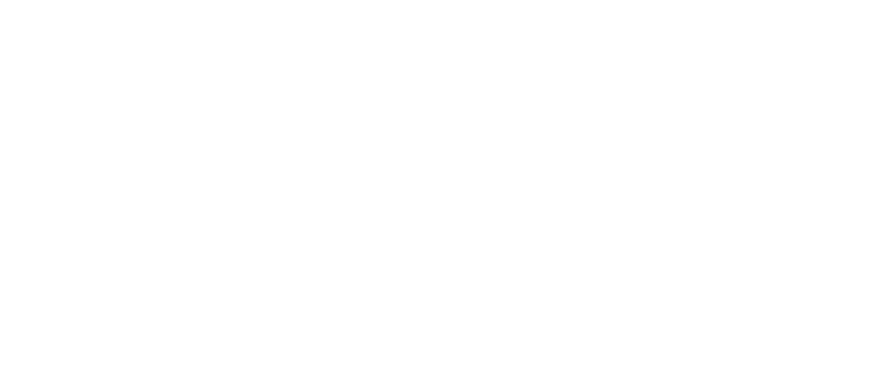

# Taller Introducción a la IA: DBScan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
sns.set(style="whitegrid")

In [ ]:
X, y = make_blobs(n_samples=800,
                  centers=4,
                  cluster_std=[0.5, 0.1, 0.9, 0.35],
                  random_state=42)

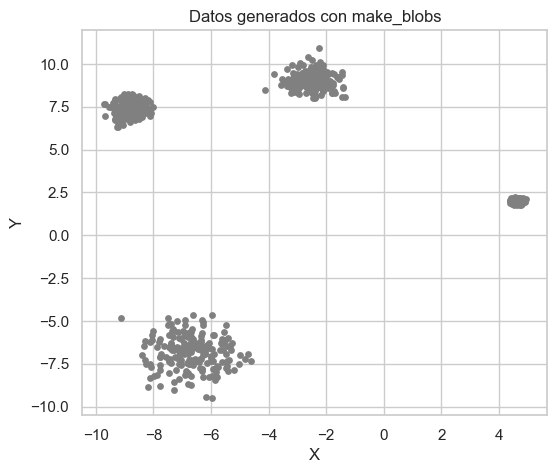

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=15, color='gray')
plt.title("Datos generados con make_blobs")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

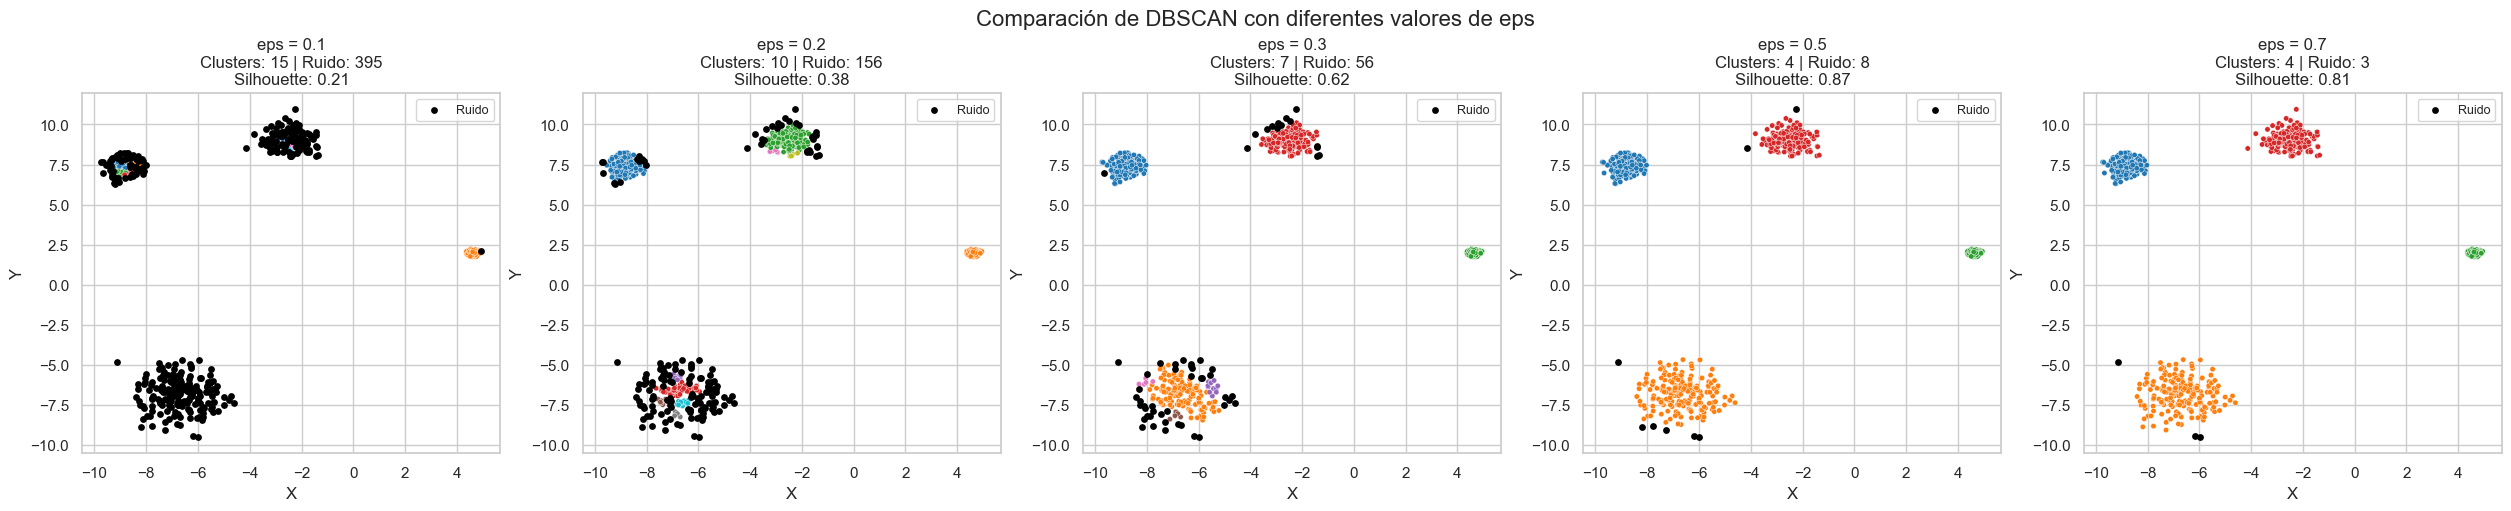

In [ ]:
eps_values = [0.1, 0.2, 0.3, 0.5, 0.7]

best_score = -1
best_eps = None
best_labels = None

n_cols = len(eps_values)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5), constrained_layout=True)

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)  # Completar: aplicar DBSCAN a los datos

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Completar: número de clústeres
    n_noise = sum(labels == -1)  # Completar: contar puntos de ruido

    if n_clusters > 1:
        score = silhouette_score(X, labels)  # Completar: calcular Silhouette Score
        if score > best_score:
            best_score = score
            best_eps = eps
            best_labels = labels
        score_text = f"Silhouette: {score:.2f}"
    else:
        score_text = "Silhouette: N/A"

    noise_mask = labels == -1  # Completar: máscara de ruido
    core_mask = labels != -1   # Completar: máscara de puntos de clúster

    ax = axes[idx]

    sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                    hue=labels[core_mask], palette='tab10', legend=False, s=15, ax=ax)

    ax.scatter(X[noise_mask][:, 0], X[noise_mask][:, 1],
               color='black', s=15, label='Ruido')

    ax.set_title(f"eps = {eps}\nClusters: {n_clusters} | Ruido: {n_noise}\n{score_text}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle("Comparación de DBSCAN con diferentes valores de eps", fontsize=16)
plt.show()



======= MEJOR CONFIGURACIÓN =======
Mejor eps: 0.5
Silhouette Score máximo: 0.866


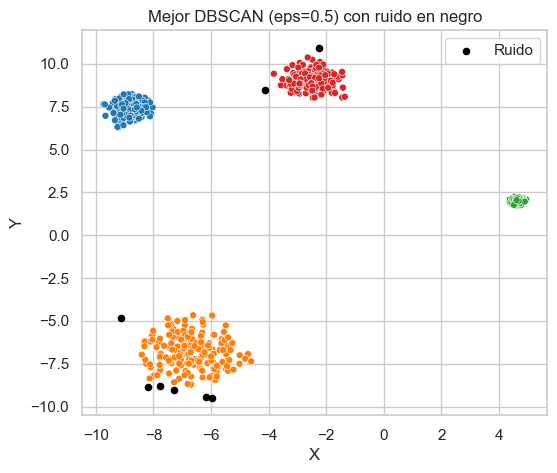

In [ ]:
print("\n======= MEJOR CONFIGURACIÓN =======")
print(f"Mejor eps: {best_eps}")  # ← Completar: mejor valor de eps encontrado
print(f"Silhouette Score máximo: {best_score:.3f}")  # ← Completar: mejor score obtenido

plt.figure(figsize=(6, 5))
core_mask = best_labels != -1  # ← Completar: máscara para puntos del clúster

sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                hue=best_labels[core_mask], palette='tab10', s=25, legend=False)

plt.scatter(X[~core_mask][:, 0], X[~core_mask][:, 1],
            color='black', s=20, label='Ruido')

plt.title(f"Mejor DBSCAN (eps={best_eps}) con ruido en negro")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

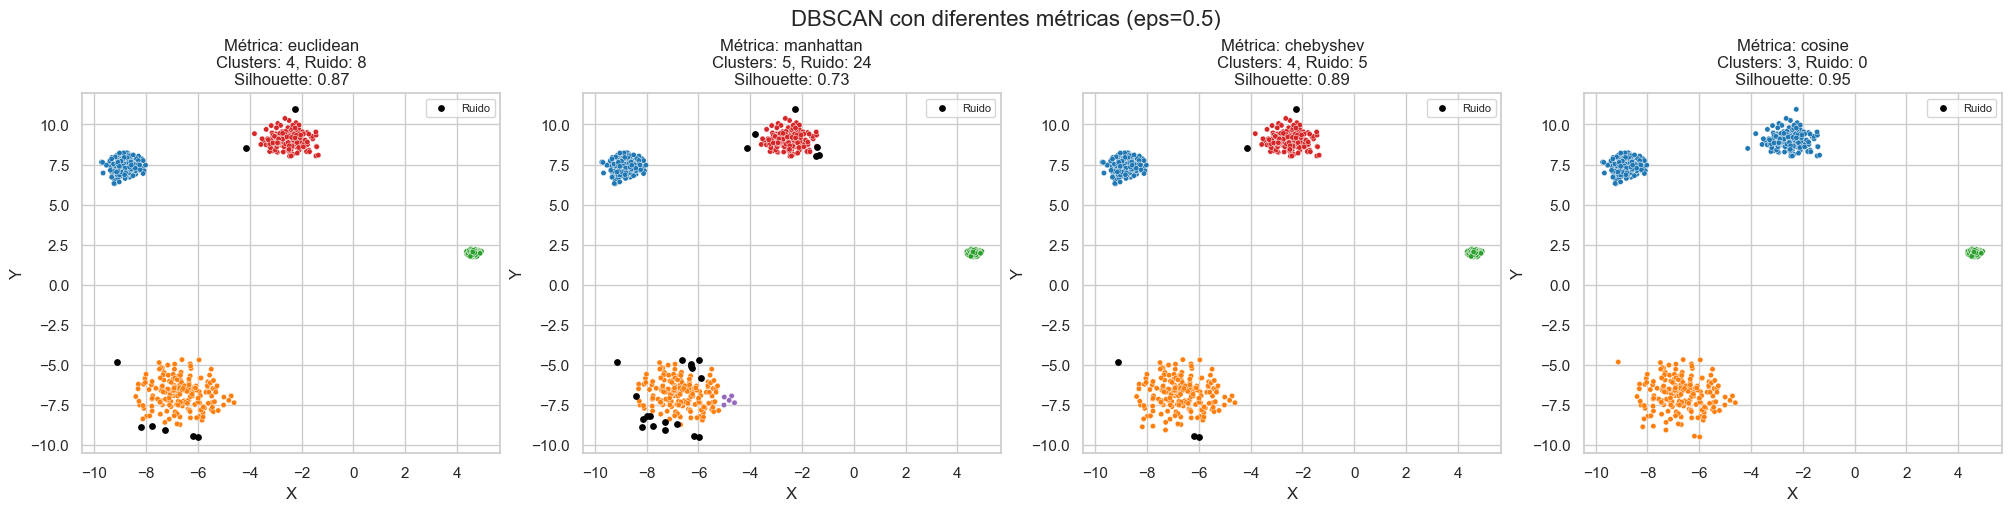

In [ ]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'cosine']
eps = 0.5

results = []

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), constrained_layout=True)

for idx, metric in enumerate(metrics):
    dbscan = DBSCAN(eps=eps, min_samples=5, metric=metric)
    labels = dbscan.fit_predict(X)  # ← Completar: aplicar DBSCAN con métrica

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # ← Completar: clústeres sin ruido
    n_noise = sum(labels == -1)  # ← Completar: cantidad de ruido

    if n_clusters > 1:
        score = silhouette_score(X, labels, metric=metric)  # ← Completar: Silhouette Score
        score_text = f"Silhouette: {score:.2f}"
    else:
        score = np.nan
        score_text = "Silhouette: N/A"

    results.append({
        'métrica': metric,
        'clusters': n_clusters,
        'ruido': n_noise,
        'silhouette_score': score
    })

    ax = axes[idx]
    noise_mask = labels == -1  # ← Completar: máscara de ruido
    core_mask = labels != -1   # ← Completar: máscara de clúster

    sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                    hue=labels[core_mask], palette='tab10', s=15, legend=False, ax=ax)

    ax.scatter(X[noise_mask][:, 0], X[noise_mask][:, 1],
               color='black', s=15, label='Ruido')

    ax.set_title(f"Métrica: {metric}\nClusters: {n_clusters}, Ruido: {n_noise}\n{score_text}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f"DBSCAN con diferentes métricas (eps={eps})", fontsize=16)
plt.show()


# **PREGUNTAS**

**1. ¿Cuál eps permitió obtener el mayor silhouette score?**  

la eps con valor 0.5

**2. ¿Cuántos clusters se obtuvieron usando el eps del punto anterior?**  

4 clusters

**3. ¿Qué sucede si el parámetro ε (epsilon) es demasiado pequeño o demasiado grande? ¿Cómo afecta esto a la cantidad de clústeres y al ruido?**  

un epsilon pequeño puede generar mas ruido  y mas clusters

**4. ¿Qué métrica de distancia produjo mejores resultados en DBSCAN según el Silhouette Score? ¿Consideras que en verdad fue el mejor resultado?**  

la mejor segun el silhouete fue la cosine, pero no se considera un buen resultado dado que agrupo dos grupos con una distancia notable en un solo cluster

**5. ¿Por qué DBSCAN es más adecuado que K-Means para detectar clústeres con formas no circulares o densidad variable?**  

dbscan no asume formas circulares mientras que means si lo hace, resultando en diferencias en la deteccion de ruido, ademas de que no necesita un k predefinido

6. En el Distrito de Análisis, algunos edificios están tan juntos que forman una gran zona densa, mientras que otros están agrupados en pequeñas áreas dispersas. ¿Por qué DBSCAN puede detectar correctamente estas formas de agrupación, mientras que otros algoritmos como K-Means podrían fallar en representarlas adecuadamente?

eso es porque dbsan no asume la forma de los clusters siempre que se cumplan los requerimientos de distancia y puntos minimos, mientras que el kmeans los agrupa en base a su centroide, pudiendo dejar puntos pertenecientes en base a su distancia al centroide

7.Durante tu análisis, DBSCAN clasifica varios edificios como “ruido”. ¿Qué representa este ruido en términos de los datos originales, y por qué puede ser útil conservarlo en lugar de eliminarlo inmediatamente?

ese ruido representa datos que no pudieron cumplir los parametros de densidad, significando que son edificios aislados.  

es importante guardar estos datos dado que seria informacion perdida que nos podria ayudar a ver patrones o tendencias.